In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
data = pd.read_csv('volume_data_summary_with_error.csv')
data_large = pd.read_csv('volume_data_summary_with_error_large.csv')

In [14]:
# concatenate the two dataframes
data_concat = pd.concat([data, data_large])

In [15]:
grouped = data_concat.groupby(['minimizer', 'nparticles'])

In [16]:
data_concat

,minimizer,nparticles,ensemble_folder,volume,volume_error
0,MXD,8,explore_bv_jammed_packing5,-0.000192,0.016268
1,MXD,8,explore_bv_jammed_packing1,-0.011169,0.016276
2,MXD,8,explore_bv_jammed_packing0,0.014718,0.016386
3,MXD,8,explore_bv_jammed_packing6,-0.005138,0.016523
4,MXD,8,explore_bv_jammed_packing9,-0.017093,0.016305
...,...,...,...,...,...
41,LBFGS,128,explore_bv_jammed_packing4,-0.298000,0.078397
42,LBFGS,128,explore_bv_jammed_packing3,-0.018944,0.074455
43,LBFGS,128,explore_bv_jammed_packing2,0.030406,0.072028
44,LBFGS,128,explore_bv_jammed_packing8,-0.171593,0.074868


In [7]:
grouped

In [19]:
volume = grouped['volume'].agg([np.mean, lambda x: np.std(x, ddof=1) / np.sqrt(len(x))]).rename(columns={'<lambda_0>': 'std_error'})
volume_error_accounted = grouped['volume_error'].agg([lambda x: np.sqrt(np.mean(x**2))]).rename(columns={'<lambda>': 'sig_F0_accounted_error'})

In [21]:
# merge the two dataframes
volume = pd.merge(volume, volume_error_accounted, left_index=True, right_index=True)

In [22]:
volume

mean  std_error  sig_F0_accounted_error
minimizer nparticles                                             
CVODE     8           0.000970   0.007378                0.016256
          16          0.003066   0.007582                0.024673
          32         -0.003902   0.013888                0.034784
          64         -0.012052   0.023065                0.050449
FIRE      32          0.012049   0.009155                0.034971
          64          0.047778   0.009817                0.048882
          128         0.012537   0.031242                0.071964
          256        -0.006034   0.030706                0.100873
          512         0.015592   0.124405                0.141656
LBFGS     64          0.002219   0.016673                0.049627
          128         0.005050   0.047245                0.073150
          256        -0.061750   0.056640                0.103121
          512        -0.220828   0.079691                0.148097
MXD       8           0.000279   0.004824                0.016266
          16         -0.011994   0.008023                0.024698
          32          0.001612   0.010864                0.034772
          64          0.018948   0.017786                0.049266

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_data_with_error_bars(df, accounted_bars=False):
    # Set the style of seaborn
    sns.set_style("darkgrid")

    # Initialize the matplotlib figure
    plt.figure(figsize=(10, 6))

    # Loop through each unique minimizer to plot them as separate lines
    for minimizer in df['minimizer'].unique():
        sub_df = df[df['minimizer'] == minimizer]
        if accounted_bars:
            error = sub_df['sig_F0_accounted_error']
        else:
            error = sub_df['std_error']
        plt.errorbar(sub_df['nparticles']*2, sub_df['mean'], yerr=error, label=minimizer, fmt='-o', capsize=5)

    # Adding plot title and labels
    plt.title(' -Mean log Volume (F0) vs. Number of Particles by Minimizer')
    plt.xlabel('dimensions')
    plt.ylabel('Mean F0')
    
    # Adding a legend to differentiate between minimizers
    plt.legend(title='Minimizer')
    plt.xscale('log')
    # Show the plot
    plt.show()

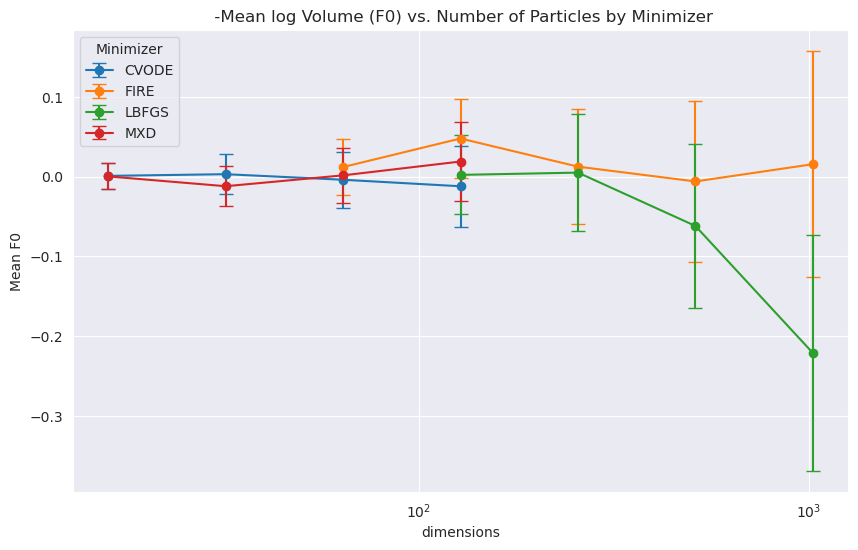

In [26]:
plot_data_with_error_bars(volume.reset_index(), accounted_bars=True)

In [30]:
# this 